Xây dựng cây quyết định (Decision Tree) trên dữ liệu Titanic lấy từ
https://www.kaggle.com/code/dmilla/introduction-to-decision-trees-titanic-dataset

# 1. Import thư viện & nạp dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_auc_score



import graphviz 


In [2]:
# Đọc dữ liệu từ file CSV
data = pd.read_csv("./data/diabetes_prediction_dataset.csv")

# Xem 5 dòng đầu tiên
print(data.head())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [3]:
# Thông tin tổng quan về kiểu dữ liệu và số null
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None


In [4]:
# Thống kê mô tả cho các cột số
print(data.describe())

                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840       0.26315       0.194593       6.636783   
min         0.080000       0.00000       0.000000      10.010000   
25%        24.000000       0.00000       0.000000      23.630000   
50%        43.000000       0.00000       0.000000      27.320000   
75%        60.000000       0.00000       0.000000      29.580000   
max        80.000000       1.00000       1.000000      95.690000   

         HbA1c_level  blood_glucose_level       diabetes  
count  100000.000000        100000.000000  100000.000000  
mean        5.527507           138.058060       0.085000  
std         1.070672            40.708136       0.278883  
min         3.500000            80.000000       0.000000  
25%         4.800000           100.000000       0.000000  
50%         5.800000           14

In [5]:
# Đếm số lượng giá trị thiếu ở mỗi cột
print(data.isna().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


# 2. Phân tích & loại bỏ features không liên quan

**Các feature giữ lại (quan trọng cho dự đoán tiểu đường)**

* **age**

  * Tuổi là yếu tố nguy cơ lớn của bệnh tiểu đường → **giữ**.

* **hypertension**

  * Tăng huyết áp liên quan chặt chẽ với rối loạn chuyển hóa → **giữ**.

* **heart_disease**

  * Bệnh tim thường đi kèm với tiểu đường → **giữ**.

* **bmi**

  * BMI cao là yếu tố nguy cơ trực tiếp → **giữ**.

* **HbA1c_level**

  * Chỉ số phản ánh đường huyết trung bình 3 tháng → **rất quan trọng – giữ**.

* **blood_glucose_level**

  * Chỉ số đường huyết hiện tại → **rất quan trọng – giữ**.


**Các feature có thể giữ nhưng cần xử lý**

* **gender**

  * Yếu tố sinh học, có thể ảnh hưởng đến nguy cơ → **giữ**, cần encode.

* **smoking_history**

  * Ảnh hưởng đến sức khỏe chuyển hóa → **giữ**, cần one-hot encoding.


 **Feature nên loại bỏ**

Dataset này **không chứa các feature thừa** như ID, text noise, hoặc cột không liên quan.

 **Không có feature nào cần loại bỏ hoàn toàn.**

Dataset này rất phù hợp để huấn luyện mô hình dự đoán bệnh tiểu đường.
Tất cả các feature đều có **mức độ liên quan nhất định** và **nên được giữ lại** (sau khi encode đối với các biến phân loại).

# 3. Tiền xử lý dữ liệu

## 3.1 Xử lý giá trị thiếu

Dữ liệu không bị thiếu nên không cần xử lí

## 3.2 Mã hoá biến phân loại (gender, smoking_history)

**gender (Label Encoding)**

Biến dạng 3 giá trị → chuyển thành số:

- Female → 0

- Male → 1

- Other → 2

**smoking_history (One-Hot Encoding)**

Các giá trị như:

- never

- current

- former

- No Info

- ever

- not current

→ được chuyển thành nhiều cột nhị phân.

drop_first=True giúp tránh multicollinearity.

In [7]:
# ------------------------------
# 1. Encode gender (Label Encoding)
# ------------------------------
gender_map = {
    'Male': 1,
    'Female': 0,
    'Other': 2
}
data['gender'] = data['gender'].map(gender_map)

# ------------------------------
# 2. One-Hot Encode smoking_history
# ------------------------------
data_encoded = pd.get_dummies(data, columns=['smoking_history'], drop_first=True)

print(data_encoded.head())
print(data_encoded.columns)


   gender   age  hypertension  heart_disease    bmi  HbA1c_level  \
0       0  80.0             0              1  25.19          6.6   
1       0  54.0             0              0  27.32          6.6   
2       1  28.0             0              0  27.32          5.7   
3       0  36.0             0              0  23.45          5.0   
4       1  76.0             1              1  20.14          4.8   

   blood_glucose_level  diabetes  smoking_history_current  \
0                  140         0                    False   
1                   80         0                    False   
2                  158         0                    False   
3                  155         0                     True   
4                  155         0                     True   

   smoking_history_ever  smoking_history_former  smoking_history_never  \
0                 False                   False                   True   
1                 False                   False                  False   
2 

# 4. Chia tập train/test

In [9]:
# Biến đầu vào X và nhãn y
X = data_encoded.drop('diabetes', axis=1)
y = data_encoded['diabetes']

# Chia train/test (vd: 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Kích thước tập train:", X_train.shape)
print("Kích thước tập test :", X_test.shape)


Kích thước tập train: (80000, 12)
Kích thước tập test : (20000, 12)


# 5 Áp dụng mô hình DecisionTreeClassifier

Huấn luyện DecisionTreeClassifier

Giải thích:

- criterion='entropy': dùng Information Gain (ID3 style). Có thể dùng 'gini' (CART).

- max_depth=4: giúp cây không quá sâu, dễ vẽ & dễ hiểu.

- classification_report cho biết precision, recall, f1-score cho từng lớp (0: chết, 1: sống).

In [10]:
# Khởi tạo cây quyết định
dt = DecisionTreeClassifier(
    criterion='entropy',  # dùng entropy (Information Gain)
    max_depth=4,          # giới hạn độ sâu để tránh overfitting
    random_state=42
)

# Huấn luyện
dt.fit(X_train, y_train)

# Dự đoán trên tập test
y_pred = dt.predict(X_test)

# Đánh giá
print("Accuracy trên tập test:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy trên tập test: 0.9723
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     18300
           1       1.00      0.67      0.81      1700

    accuracy                           0.97     20000
   macro avg       0.99      0.84      0.90     20000
weighted avg       0.97      0.97      0.97     20000



## 5.1 Vẽ cây quyết định bằng graphviz

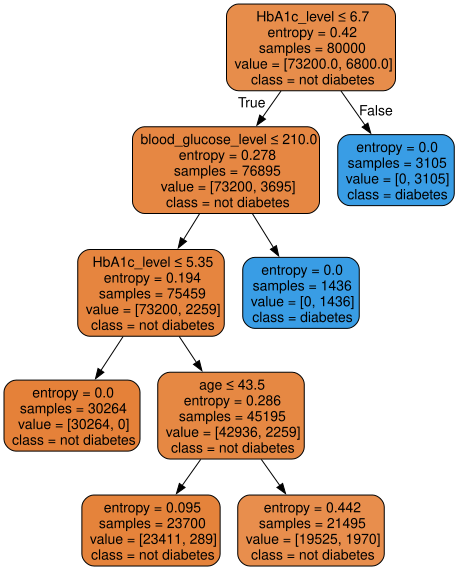

In [12]:
# Tên các features sau khi encode
feature_names = X.columns

# Tên các lớp
class_names = ['not diabetes', 'diabetes']

# Xuất ra chuỗi dot
dot_data = export_graphviz(
    dt,
    out_file=None,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,        # tô màu nút theo lớp
    rounded=True,       # bo tròn góc
    special_characters=True
)

# Tạo graph từ dot_data
graph = graphviz.Source(dot_data)

# Hiển thị trực tiếp trong Jupyter Notebook:
graph


## 5.2 Dùng GridSearchCV để tìm tham số tối ưu

Chạy GridSearchCV

- cv.best_params_ → max_depth tối ưu

- cv.best_score_ → AUC tốt nhất khi cross-validation

In [13]:
params = {'max_depth':[1, 2, 4, 6, 8, 10, 12]}  # các giá trị max_depth

cv = GridSearchCV(
    dt,
    param_grid=params,
    scoring='roc_auc',
    n_jobs=None,
    refit=True,
    cv=4,
    verbose=1,
    error_score=np.nan,
    return_train_score=True
)

cv.fit(X_train, y_train)

print("Best params:", cv.best_params_)
print("Best ROC-AUC:", cv.best_score_)


Fitting 4 folds for each of 7 candidates, totalling 28 fits
Best params: {'max_depth': 10}
Best ROC-AUC: 0.9730063243330119


## 5.3 Vẽ biểu đồ đánh giá mô hình

In [14]:
results = pd.DataFrame(cv.cv_results_)
results[['param_max_depth', 'mean_train_score', 'mean_test_score']]

,param_max_depth,mean_train_score,mean_test_score
0,1,0.728309,0.728309
1,2,0.833897,0.833897
2,4,0.944023,0.943304
3,6,0.969172,0.968202
4,8,0.974782,0.972672
5,10,0.977751,0.973006
6,12,0.981195,0.964352


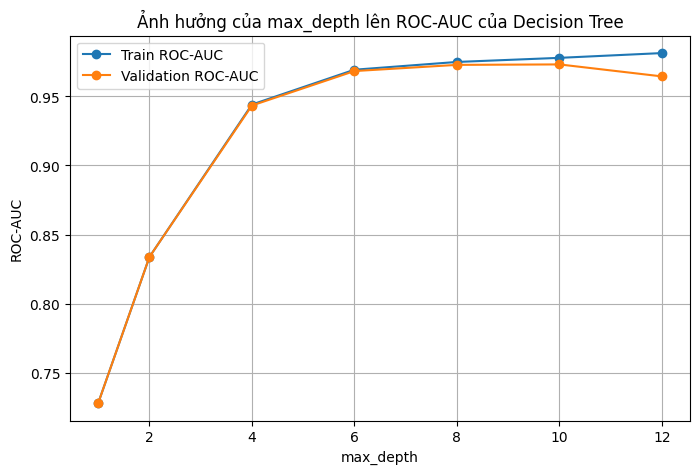

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(results['param_max_depth'], results['mean_train_score'], marker='o', label='Train ROC-AUC')
plt.plot(results['param_max_depth'], results['mean_test_score'], marker='o', label='Validation ROC-AUC')

plt.xlabel("max_depth")
plt.ylabel("ROC-AUC")
plt.title("Ảnh hưởng của max_depth lên ROC-AUC của Decision Tree")
plt.grid(True)
plt.legend()
plt.show()


## 5.4 Dùng mô hình tốt nhất để dự đoán trên tập test

In [16]:
best_dt = cv.best_estimator_

y_pred = best_dt.predict(X_test)
y_pred_proba = best_dt.predict_proba(X_test)[:, 1]


print("Test ROC-AUC:", roc_auc_score(y_test, y_pred_proba))


Test ROC-AUC: 0.9735531018964964


# 6. Áp dụng mô hình RandomForestClassifier

Huấn luyện RandomForestClassifier

Giải thích:

- n_estimators: số cây trong rừng

- max_depth: độ sâu tối đa mỗi cây

- min_samples_split: số mẫu tối thiểu để tách node

In [17]:

# Khởi tạo mô hình RandomForest
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1 # cho phép dùng nhiều core
)

# Lưới tham số để thử
param_grid_rf = {
    'n_estimators': [10, 50, 100, 200, 300, 500],
    'max_depth': [None, 4, 6, 8],
    'min_samples_split': [2, 5]
}

# GridSearchCV
rf_cv = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring='roc_auc',
    cv=4,
    refit=True,
    verbose=1,
    return_train_score=True
)

# Huấn luyện tìm tham số tốt nhất
rf_cv.fit(X_train, y_train)

print("Best params (Random Forest):", rf_cv.best_params_)
print("Best CV ROC-AUC:", rf_cv.best_score_)

Fitting 4 folds for each of 48 candidates, totalling 192 fits
Best params (Random Forest): {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 500}
Best CV ROC-AUC: 0.9698474967855994


## 6.1 Tìm tham số tối ưu cho mô hình rừng cây và thực hiện train với tham số tối ưu đó

In [17]:
rf_params_ex = {'n_estimators':list(range(10,110,10))}

cv_rf_ex = GridSearchCV(
    rf,
    param_grid=rf_params_ex,
    scoring='roc_auc',
    n_jobs=None,
    refit=True,
    cv=4,
    verbose=1,
    error_score=np.nan,
    return_train_score=True
)

cv_rf_ex.fit(X_train, y_train)


Fitting 4 folds for each of 10 candidates, totalling 40 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'n_estimators': [10, 20, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,10


In [18]:
print("Best params:", cv_rf_ex.best_params_)
print("Best CV ROC-AUC:", cv_rf_ex.best_score_)

Best params: {'n_estimators': 10}
Best CV ROC-AUC: 0.8717813584530161


In [19]:
best_rf = cv_rf_ex.best_estimator_

# Dự đoán
y_pred = best_rf.predict(X_test)
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]


print("Test ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Test ROC-AUC: 0.8331357048748353
Test Accuracy: 0.8156424581005587
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



## 6.2 Vẽ biểu đồ đánh giá mô hình rừng cây với các tham số số cây có trong rừng khác nhau

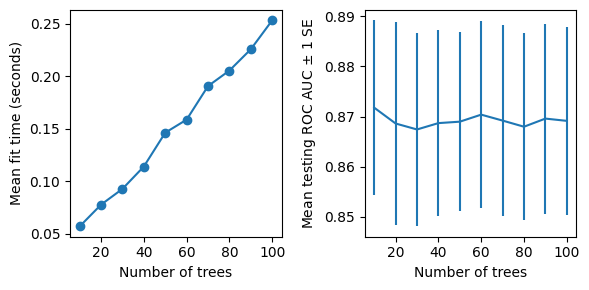

In [20]:
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs[0].plot(cv_rf_ex_results_df['param_n_estimators'],
cv_rf_ex_results_df['mean_fit_time'],
'-o')
axs[0].set_xlabel('Number of trees')
axs[0].set_ylabel('Mean fit time (seconds)')
axs[1].errorbar(cv_rf_ex_results_df['param_n_estimators'],
cv_rf_ex_results_df['mean_test_score'],
yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4))
axs[1].set_xlabel('Number of trees')
axs[1].set_ylabel('Mean testing ROC AUC $\\pm$ 1 SE ')
plt.tight_layout()

## 6.3 Xem tham số tốt nhất của rừng cây, xem mức độ quan trọng của từng feature trong mô hình với tham số tốt nhất

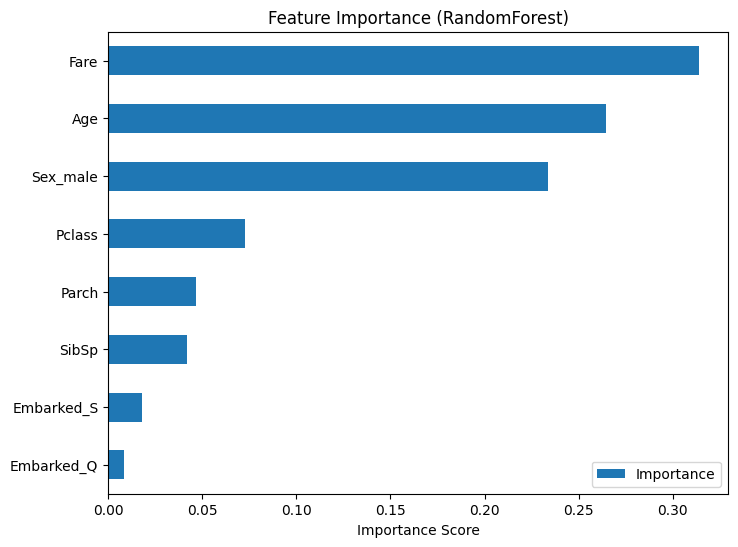

In [21]:
feat_imp_df = pd.DataFrame({
    'Importance': best_rf.feature_importances_
}, index=X.columns)   # bỏ cột Survived

# Sắp xếp & vẽ biểu đồ
feat_imp_df.sort_values('Importance', ascending=True).plot.barh(figsize=(8,6))
plt.title("Feature Importance (RandomForest)")
plt.xlabel("Importance Score")
plt.show()

# Kết thúc